<a href="https://colab.research.google.com/github/truongchinh1211/Predicting-Cinema-Hall-Revenue/blob/main/Predicting_Cinema_Hall_Revenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

100%|██████████| 8.89M/8.89M [00:00<00:00, 39.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from ast import literal_eval

movies  = pd.read_csv( path+ '/tmdb_5000_movies.csv')
credits = pd.read_csv(path+'/tmdb_5000_credits.csv')

df = movies.merge(credits, left_on='id', right_on='movie_id',
                  how='left', suffixes=('', '_cred'))

In [4]:
df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# ----- STEP 3 – Log-transform skewed numeric columns ----------
df['log_budget']  = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])

# ----- STEP 4 – JSON-based features ---------------------------
def list_len(text):
    try:
        return len(literal_eval(text))
    except (ValueError, SyntaxError, TypeError):
        return 0

df['num_cast']   = df['cast'].apply(list_len)
df['num_crew']   = df['crew'].apply(list_len)
df['num_genres'] = df['genres'].apply(list_len)

# ---------- NEW: extract director & top-5 cast ----------------
def get_director(crew_str):
    try:
        for member in literal_eval(crew_str):
            if member.get('job') == 'Director':
                return member.get('name')
    except (ValueError, SyntaxError, TypeError):
        pass
    return None

def get_top_cast(cast_str, n=5):
    try:
        cast = literal_eval(cast_str)
        # sort by billing order (0 là vai chính nhất)
        top = sorted(cast, key=lambda x: x.get('order', 100))[:n]
        names = [c['name'] for c in top]
        # nếu phim có < n diễn viên thì pad None
        names += [None]*(n-len(names))
        return names
    except (ValueError, SyntaxError, TypeError):
        return [None]*n

# áp dụng
df['director'] = df['crew'].apply(get_director)
cast_cols = [f'cast_{i+1}' for i in range(5)]
df[cast_cols] = df['cast'].apply(lambda x: pd.Series(get_top_cast(x, 5), index=cast_cols))

# ----- STEP 5 – Compact dataframe for modelling ---------------
prep_cols = [
    'id', 'title', 'release_year', 'release_month',
    'director', *cast_cols,          # <-- các cột mới
    'log_budget', 'log_revenue',
    'popularity', 'runtime', 'vote_average', 'vote_count',
    'num_cast', 'num_crew', 'num_genres'
]

model_df = df[prep_cols].copy()
    # sẵn sàng cho EDA hoặc pipeline

In [5]:
model_df.head()

,id,title,release_year,release_month,director,cast_1,cast_2,cast_3,cast_4,cast_5,log_budget,log_revenue,popularity,runtime,vote_average,vote_count,num_cast,num_crew,num_genres
0,19995,Avatar,2009.0,12.0,James Cameron,Sam Worthington,Zoe Saldana,Sigourney Weaver,Stephen Lang,Michelle Rodriguez,19.283571,21.748578,150.437577,162.0,7.2,11800,83,153,4
1,285,Pirates of the Caribbean: At World's End,2007.0,5.0,Gore Verbinski,Johnny Depp,Orlando Bloom,Keira Knightley,Stellan Skarsgård,Chow Yun-fat,19.519293,20.683485,139.082615,169.0,6.9,4500,34,32,3
2,206647,Spectre,2015.0,10.0,Sam Mendes,Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph Fiennes,Monica Bellucci,19.316769,20.596199,107.376788,148.0,6.3,4466,83,155,3
3,49026,The Dark Knight Rises,2012.0,7.0,Christopher Nolan,Christian Bale,Michael Caine,Gary Oldman,Anne Hathaway,Tom Hardy,19.336971,20.804790,112.312950,165.0,7.6,9106,158,217,4
4,49529,John Carter,2012.0,3.0,Andrew Stanton,Taylor Kitsch,Lynn Collins,Samantha Morton,Willem Dafoe,Thomas Haden Church,19.376192,19.464974,43.926995,132.0,6.1,2124,27,132,3


In [11]:
from scipy.stats import skew, kurtosis
from IPython.display import display
cols = ['budget', 'revenue']
stats = []

for col in cols:
    series = df[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)].shape[0]

    stats.append({
        'Column': col,
        'Min': series.min(),
        'Q1': q1,
        'Median': series.median(),
        'Mean': series.mean(),
        'Q3': q3,
        'Max': series.max(),
        'Skewness': skew(series),
        'Kurtosis': kurtosis(series, fisher=False),
        'Outlier count (IQR)': outliers
    })

raw_stats_df = pd.DataFrame(stats).round({'Mean':0,'Median':0,'Min':0,'Max':0,'Q1':0,'Q3':0,'Skewness':2,'Kurtosis':2})

# Apply log1p transform
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])

cols_log = ['log_budget', 'log_revenue']
stats_log = []

for col in cols_log:
    series = df[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)].shape[0]

    stats_log.append({
        'Column': col,
        'Min': series.min(),
        'Q1': q1,
        'Median': series.median(),
        'Mean': series.mean(),
        'Q3': q3,
        'Max': series.max(),
        'Skewness': skew(series),
        'Kurtosis': kurtosis(series, fisher=False),
        'Outlier count (IQR)': outliers
    })

log_stats_df = pd.DataFrame(stats_log).round({'Mean':2,'Median':2,'Min':2,'Max':2,'Q1':2,'Q3':2,'Skewness':2,'Kurtosis':2})
display(raw_stats_df)
display(log_stats_df)

,Column,Min,Q1,Median,Mean,Q3,Max,Skewness,Kurtosis,Outlier count (IQR)
0,budget,0,790000.0,15000000.0,29045040.0,40000000.0,380000000,2.44,10.65,321
1,revenue,0,0.0,19170001.0,82260639.0,92917187.0,2787965087,4.44,36.09,472


,Column,Min,Q1,Median,Mean,Q3,Max,Skewness,Kurtosis,Outlier count (IQR)
0,log_budget,0.0,13.58,16.52,13.00,17.50,19.76,-1.22,2.65,1069
1,log_revenue,0.0,0.00,16.77,12.22,18.35,21.75,-0.76,1.70,0


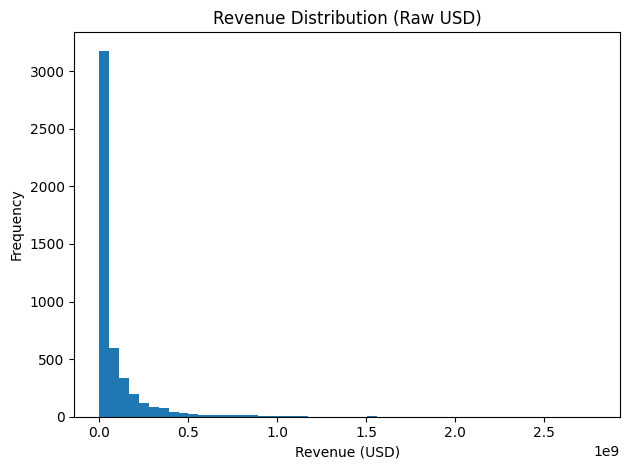

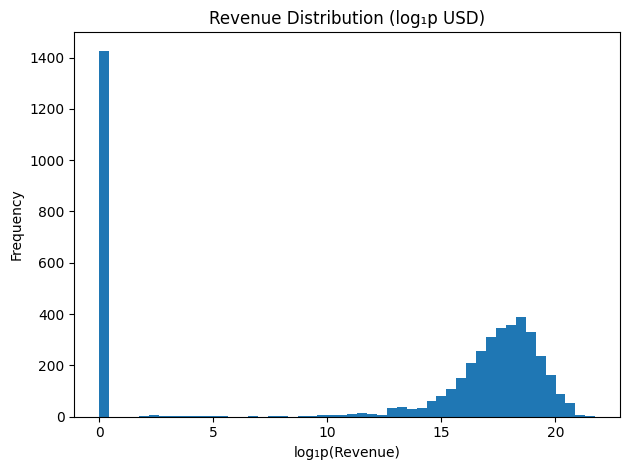

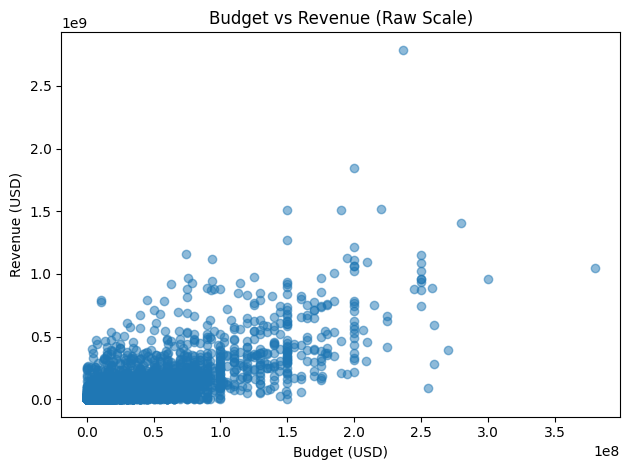

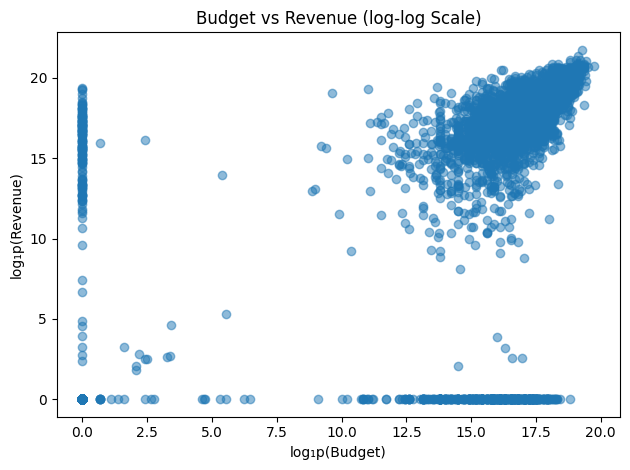

In [14]:
# Histogram of raw revenue
plt.figure()
plt.hist(df['revenue'].dropna(), bins=50)
plt.title("Revenue Distribution (Raw USD)")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Histogram of log‑revenue
plt.figure()
plt.hist(df['log_revenue'].dropna(), bins=50)
plt.title("Revenue Distribution (log₁p USD)")
plt.xlabel("log₁p(Revenue)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Scatter raw Budget vs Revenue
plt.figure()
plt.scatter(df['budget'], df['revenue'], alpha=0.5)
plt.title("Budget vs Revenue (Raw Scale)")
plt.xlabel("Budget (USD)")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

# Scatter log‑log Budget vs Revenue
plt.figure()
plt.scatter(df['log_budget'], df['log_revenue'], alpha=0.5)
plt.title("Budget vs Revenue (log‑log Scale)")
plt.xlabel("log₁p(Budget)")
plt.ylabel("log₁p(Revenue)")
plt.tight_layout()
plt.show()

In [16]:
def missing_report(df):
    miss = df.isna().sum()
    miss_pct = (miss / len(df) * 100).round(1)
    out = pd.concat([miss, miss_pct], axis=1)
    out.columns = ['Missing (#)', 'Missing (%)']
    return out[out['Missing (#)'] > 0].sort_values('Missing (%)', ascending=False)

missing_report(model_df)

,Missing (#),Missing (%)
cast_5,169,3.5
cast_4,93,1.9
cast_3,63,1.3
cast_2,53,1.1
cast_1,43,0.9
director,30,0.6
release_year,1,0.0
release_month,1,0.0
runtime,2,0.0


In [20]:
df.fillna({'release_year': 0, 'release_month': 0}, inplace=True)

'Top 10 Directors by Median Revenue (USD)'

,director,Median_Revenue
0,Joss Whedon,1.405404e+09
1,Chris Buck,1.274219e+09
2,Kyle Balda,1.156731e+09
3,Lee Unkrich,1.066970e+09
4,David Yates,9.339592e+08
5,Peter Jackson,9.262874e+08
6,Chris Renaud,8.759583e+08
7,Roger Allers,7.882418e+08
8,Tim Miller,7.831130e+08
9,George Lucas,7.753980e+08


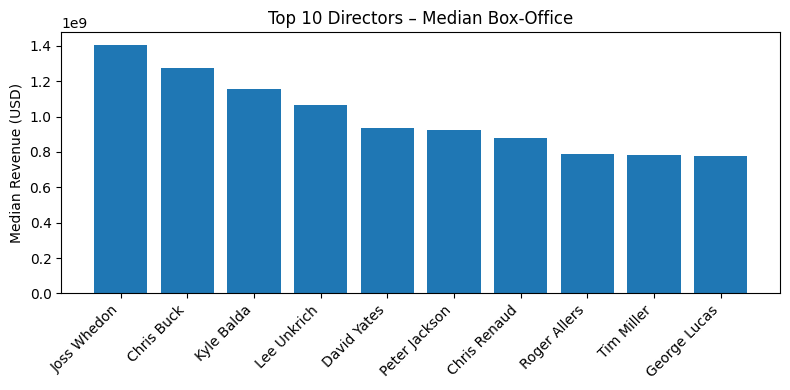

In [23]:
top_directors = (df.groupby('director')['revenue']
                   .median()
                   .sort_values(ascending=False)
                   .head(10))

display("Top 10 Directors by Median Revenue (USD)",
                          top_directors.reset_index().rename(columns={'revenue':'Median_Revenue'}))

# Bar plot
plt.figure(figsize=(8,4))
plt.bar(top_directors.index, top_directors.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Median Revenue (USD)")
plt.title("Top 10 Directors – Median Box‑Office")
plt.tight_layout()
plt.show()

In [24]:
genre_rows = (
    df[['id', 'genres', 'revenue']]
      .explode('genres')                            # mỗi phim có nhiều thể loại
      .dropna(subset=['genres'])
)

# cột 'genres' hiện dạng str JSON, đổi sang dict rồi lấy name
genre_rows['genre'] = genre_rows['genres'].apply(lambda x: literal_eval(x)['name'])

# median revenue theo thể loại
genre_med = (genre_rows.groupby('genre')['revenue']
                         .median()
                         .sort_values(ascending=False))

# vẽ biểu đồ cột
plt.figure(figsize=(8,4))
sns.barplot(x=genre_med.index, y=genre_med.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median revenue (USD)')
plt.title('Median Box-Office by Genre')
plt.show()

TypeError: list indices must be integers or slices, not str

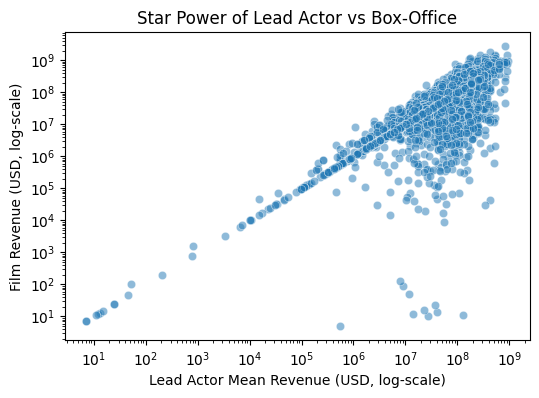

Pearson r = 0.671


In [27]:
actor_mean_rev = (df.groupby('cast_1')['revenue']
                    .mean()
                    .to_dict())

# 2) cột star_power = average revenue lịch sử của cast_1
df['star_power'] = df['cast_1'].map(actor_mean_rev)

# 3) scatter star_power ~ revenue
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='star_power', y='revenue', alpha=.5)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Lead Actor Mean Revenue (USD, log-scale)')
plt.ylabel('Film Revenue (USD, log-scale)')
plt.title('Star Power of Lead Actor vs Box-Office')
plt.show()

# 4) tương quan
print('Pearson r =',
      df[['star_power','revenue']].corr().iloc[0,1].round(3))

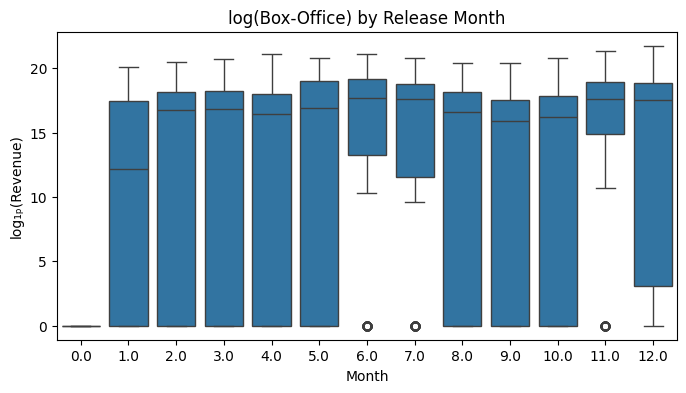

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x='release_month', y='log_revenue', data=df)
plt.title('log(Box-Office) by Release Month')
plt.xlabel('Month')
plt.ylabel('log₁ₚ(Revenue)')
plt.show()

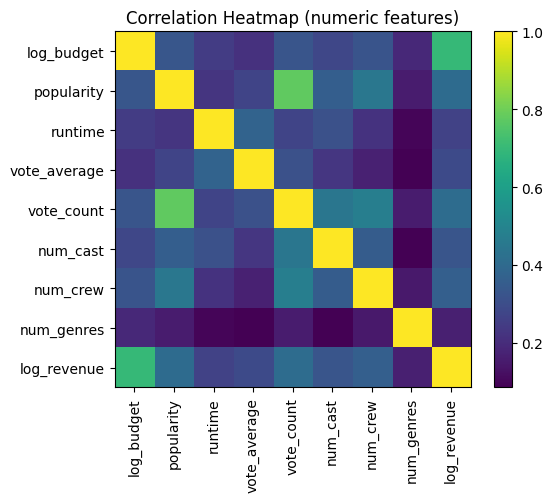

In [21]:
num_cols = ['log_budget','popularity','runtime','vote_average',
            'vote_count','num_cast','num_crew','num_genres','log_revenue']

corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='none')
plt.xticks(ticks=range(len(num_cols)), labels=num_cols, rotation=90)
plt.yticks(ticks=range(len(num_cols)), labels=num_cols)
plt.title("Correlation Heatmap (numeric features)")
plt.colorbar()
plt.tight_layout()
plt.show()

<ipython-input-29-3516b60213a6>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_med.index, y=genre_med.values, palette='viridis')


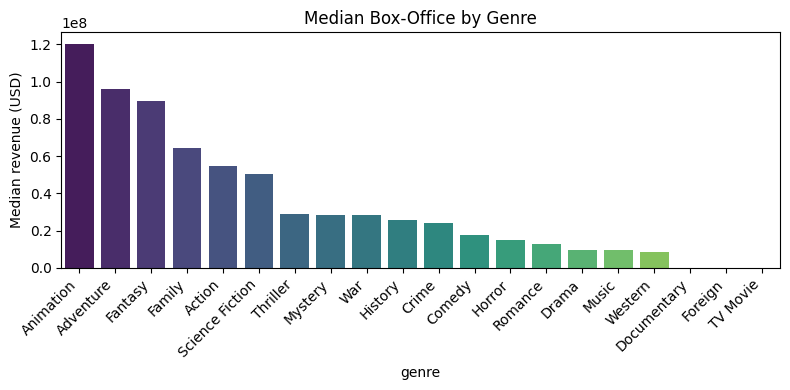

In [29]:
df['genres'] = df['genres'].apply(
    lambda x: literal_eval(x) if isinstance(x, str) else x
)

# --- B2. Nổ (explode) để mỗi dòng chỉ 1 thể loại ------------------------
genre_rows = (
    df[['id', 'genres', 'revenue']]
      .explode('genres')
      .dropna(subset=['genres'])
)

# --- B3. Lấy tên thể loại ------------------------------------------------
genre_rows['genre'] = genre_rows['genres'].apply(lambda g: g.get('name'))
# Nếu vẫn sợ có bản ghi hỏng, có thể thêm .dropna(subset=['genre'])

# --- B4. Tính median doanh thu theo thể loại ----------------------------
genre_med = (
    genre_rows.groupby('genre')['revenue']
              .median()
              .sort_values(ascending=False)
)

# --- B5. Vẽ biểu đồ ------------------------------------------------------
plt.figure(figsize=(8,4))
sns.barplot(x=genre_med.index, y=genre_med.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median revenue (USD)')
plt.title('Median Box-Office by Genre')
plt.tight_layout()
plt.show()

In [28]:
# chọn numeric & categorical
num_cols = ['log_budget','popularity','runtime','vote_average','vote_count',
            'num_cast','num_crew','num_genres','star_power']

cat_cols = ['director','cast_1','cast_2','cast_3','cast_4','cast_5']

# drop hàng thiếu star_power (rất ít) hoặc impute 0
df['star_power'] = df['star_power'].fillna(0)

# train/test split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_df[num_cols + cat_cols]
y_train = train_df['log_revenue']
X_test  = test_df[num_cols + cat_cols]
y_test  = test_df['log_revenue']

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline  import Pipeline
from sklearn.impute    import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd, numpy as np

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot' , OneHotEncoder(drop='first', handle_unknown='ignore'))
])

prep = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    'GradientBoost' : GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            objective='reg:squarederror', random_state=42, n_jobs=-1)
}

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    results.append({
        'Model': name,
        'RMSE_log':  round(rmse(y_test, pred_log), 3),
        'MAE_log' :  round(mean_absolute_error(y_test, pred_log), 3),
        'R2_log'  :  round(r2_score(y_test, pred_log), 3),
        'RMSE_USD':  f"{rmse(np.expm1(y_test), np.expm1(pred_log)) :,.0f}",
        'MAE_USD' :  f"{mean_absolute_error(np.expm1(y_test), np.expm1(pred_log)) :,.0f}"
    })

pd.DataFrame(results).sort_values('RMSE_log')

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE_log,MAE_log,R2_log,RMSE_USD,MAE_USD
2,GradientBoost,4.454,2.461,0.710,"122,151,562","48,495,866"
1,RandomForest,4.466,1.954,0.708,"64,436,681","33,065,423"
3,XGBoost,4.497,2.337,0.704,"96,356,089","41,680,227"
0,Ridge,5.753,4.069,0.516,"218,243,829,665,934","7,044,489,949,470"


In [37]:
df['revenue'] = df['revenue'].astype(float)

df['rev_missing'] = (df['revenue'] == 0).astype(int)
median_log = df.loc[df['revenue'] > 0, 'log_revenue'].median()

df.loc[df['revenue'] == 0, 'log_revenue'] = median_log
df.loc[df['revenue'] == 0, 'revenue']     = np.expm1(median_log)


df['release_quarter'] = df['release_date'].dt.quarter
holiday_months = [5, 6, 7, 12]
df['is_holiday'] = df['release_month'].isin(holiday_months).astype(int)
num_cols = ['log_budget','popularity','runtime','vote_average','vote_count',
            'num_cast','num_crew','num_genres','star_power',
            'rev_missing','is_holiday']

cat_cols = ['director', *cast_cols, 'release_quarter']

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
X_train = train_df[num_cols + cat_cols]
y_train = train_df['log_revenue']
X_test  = test_df[num_cols + cat_cols]
y_test  = test_df['log_revenue']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot' , OneHotEncoder(drop='first', handle_unknown='ignore'))
])

prep = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    'GradientBoost' : GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            objective='reg:squarederror', random_state=42, n_jobs=-1)
}

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    results.append({
        'Model': name,
        'RMSE_log':  round(rmse(y_test, pred_log), 3),
        'MAE_log' :  round(mean_absolute_error(y_test, pred_log), 3),
        'R2_log'  :  round(r2_score(y_test, pred_log), 3),
        'RMSE_USD':  f"{rmse(np.expm1(y_test), np.expm1(pred_log)) :,.0f}",
        'MAE_USD' :  f"{mean_absolute_error(np.expm1(y_test), np.expm1(pred_log)) :,.0f}"
    })

pd.DataFrame(results).sort_values('RMSE_log')

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE_log,MAE_log,R2_log,RMSE_USD,MAE_USD
3,XGBoost,0.869,0.466,0.745,"67,776,385","33,383,200"
1,RandomForest,0.870,0.423,0.744,"62,518,670","30,526,066"
2,GradientBoost,0.944,0.498,0.699,"73,521,916","34,675,290"
0,Ridge,1.371,0.912,0.365,"3,058,390,412","199,661,096"


In [38]:
!pip -q install lightgbm catboost

from lightgbm import LGBMRegressor
lgbm = LGBMRegressor(
        n_estimators=1500, learning_rate=0.05,
        max_depth=-1, num_leaves=255,
        subsample=0.8, colsample_bytree=0.8,
        objective='regression', random_state=42)

pipe = Pipeline([('prep', prep), ('model', lgbm)])
pipe.fit(X_train, y_train)
pred_log = pipe.predict(X_test)
print("LightGBM RMSE_log:", rmse(y_test, pred_log))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1451
[LightGBM] [Info] Number of data points in the train set: 3842, number of used features: 27
[LightGBM] [Info] Start training from score 17.481731
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM RMSE_log: 0.9559292203341719


In [42]:
def extract_genre_names(g):
    """
    Nhận đầu vào đủ kiểu (str JSON, list, dict) và
    trả về list tên thể loại (list[str]).
    """
    if isinstance(g, str):
        try:
            g = literal_eval(g)
        except Exception:
            return []

    if isinstance(g, list):
        names = []
        for item in g:
            if isinstance(item, dict) and 'name' in item:
                names.append(item['name'])
            elif isinstance(item, str):
                names.append(item)
        return names

    if isinstance(g, dict) and 'name' in g:
        return [g['name']]

    return []  # ngược lại

In [45]:
df['genres_list'] = df['genres'].apply(extract_genre_names)
num_cols = ['log_budget','popularity','runtime','vote_average','vote_count',
            'num_cast','num_crew','num_genres','star_power']

cat_cols = ['director','cast_1','cast_2','cast_3','cast_4','cast_5']
df['primary_genre'] = df['genres_list'].apply(lambda lst: lst[0] if lst else 'Unknown')
cat_cols.append('primary_genre')

# drop hàng thiếu star_power (rất ít) hoặc impute 0
df['star_power'] = df['star_power'].fillna(0)

# train/test split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_df[num_cols + cat_cols]
y_train = train_df['log_revenue']
X_test  = test_df[num_cols + cat_cols]
y_test  = test_df['log_revenue']
from sklearn.compose import ColumnTransformer
from sklearn.pipeline  import Pipeline
from sklearn.impute    import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd, numpy as np

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot' , OneHotEncoder(drop='first', handle_unknown='ignore'))
])

prep = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    'GradientBoost' : GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8,
                            objective='reg:squarederror', random_state=42, n_jobs=-1)
}

def rmse(y_true, y_pred):           # phiên bản không phụ thuộc sklearn new
    return mean_squared_error(y_true, y_pred) ** 0.5

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    results.append({
        'Model': name,
        'RMSE_log':  round(rmse(y_test, pred_log), 3),
        'MAE_log' :  round(mean_absolute_error(y_test, pred_log), 3),
        'R2_log'  :  round(r2_score(y_test, pred_log), 3),
        'RMSE_USD':  f"{rmse(np.expm1(y_test), np.expm1(pred_log)) :,.0f}",
        'MAE_USD' :  f"{mean_absolute_error(np.expm1(y_test), np.expm1(pred_log)) :,.0f}"
    })

pd.DataFrame(results).sort_values('RMSE_log')

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE_log,MAE_log,R2_log,RMSE_USD,MAE_USD
2,GradientBoost,1.065,0.631,0.617,"75,908,564","38,074,072"
1,RandomForest,1.103,0.566,0.589,"63,186,293","33,670,578"
3,XGBoost,1.278,0.640,0.448,"70,492,814","36,759,331"
0,Ridge,1.496,0.991,0.244,"1,083,486,917","117,018,154"


In [49]:
for c in cat_cols:
    df[c] = df[c].astype('category')

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
X_train = train_df[num_cols + cat_cols]
y_train = train_df['log_revenue']
X_test  = test_df[num_cols + cat_cols]
y_test  = test_df['log_revenue']
# 1) Khởi tạo LGBMRegressor ------------------------------------
import lightgbm as lgb
lgbm = lgb.LGBMRegressor(
        n_estimators     = 3000,
        learning_rate    = 0.05,
        num_leaves       = 255,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        objective        = 'regression',
        random_state     = 42,
        n_jobs           = -1
)

# 2) Train với early-stopping qua callback ----------------------
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    categorical_feature=cat_cols,          # tên cột cat
    callbacks=[lgb.early_stopping(200, verbose=False)]
)

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5  # tính RMSE

# Dự đoán với mô hình đã huấn luyện
pred_log = lgbm.predict(X_test)

# Tính toán các chỉ số đánh giá
rmse_log = rmse(y_test, pred_log)  # RMSE (log scale)
mae_log = mean_absolute_error(y_test, pred_log)  # MAE (log scale)
r2_log = r2_score(y_test, pred_log)  # R2 (log scale)

# Chuyển đổi về doanh thu USD từ log scale
true_usd = np.expm1(y_test)
pred_usd = np.expm1(pred_log)

rmse_usd = np.sqrt(mean_squared_error(true_usd, pred_usd))  # Tính căn bậc hai của MSE
mae_usd = mean_absolute_error(true_usd, pred_usd)

# In kết quả chi tiết
print(f"LightGBM Results:")
print(f"RMSE_log: {rmse_log:.3f}")
print(f"MAE_log: {mae_log:.3f}")
print(f"R²_log: {r2_log:.3f}")
print(f"RMSE_USD: {rmse_usd:,.0f}")
print(f"MAE_USD: {mae_usd:,.0f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060017 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3213
[LightGBM] [Info] Number of data points in the train set: 3842, number of used features: 16
[LightGBM] [Info] Start training from score 17.481731
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

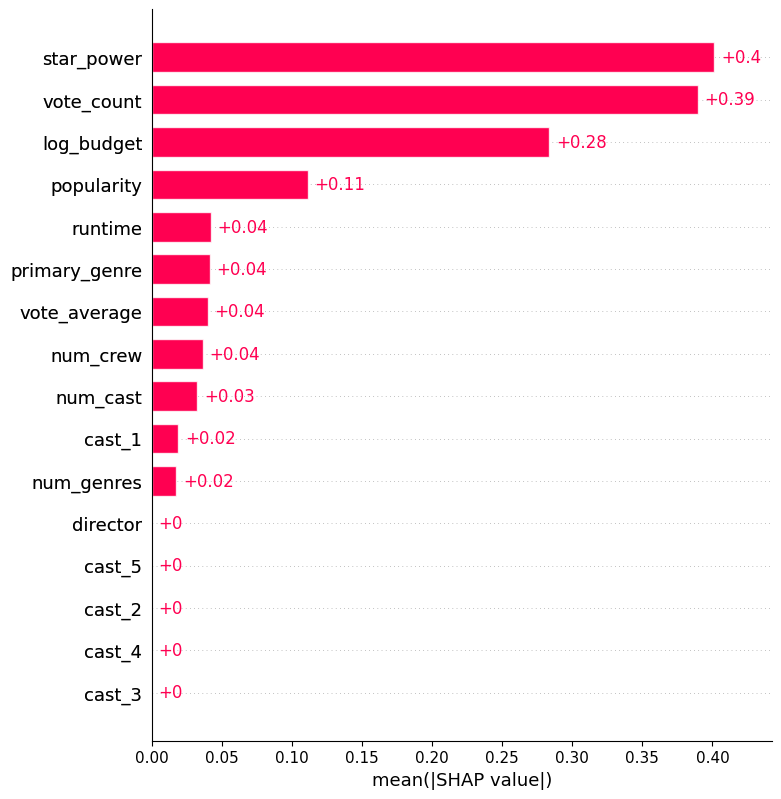

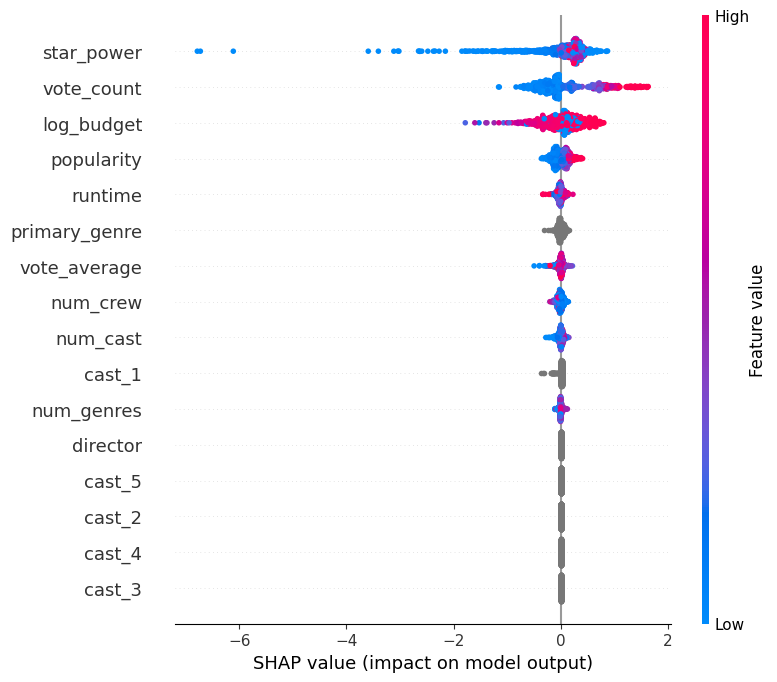

In [50]:
!pip -q install shap

import shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# LightGBM model đã train:  lgbm
# Dữ liệu test:             X_test, y_test
#   (đảm bảo X_test vẫn chứa các cột category đã ép kiểu)

# ============================================================
# 1. TẠO EXPLAINER – dùng booster nội của LGBMRegressor
# ============================================================
explainer = shap.Explainer(lgbm)

# ============================================================
# 2. TÍNH SHAP VALUES (mặc định mẫu = toàn X_test)
#    Nếu tập test quá lớn, chọn 500–1 000 dòng:
# ============================================================
X_sample = X_test.sample(800, random_state=42)  # tuỳ chỉnh
shap_values = explainer(X_sample)

# ============================================================
# 3. BIỂU ĐỒ SUMMARY BAR (Top-20)
# ============================================================
plt.figure()
shap.plots.bar(shap_values, max_display=20)     # top-20
plt.show()

# ============================================================
# 4. BIỂU ĐỒ BEESWARM (toàn bộ features)
# ============================================================
plt.figure(figsize=(10,6))
shap.plots.beeswarm(shap_values, max_display=20)   # 20 dễ xem hơn
plt.show()